# MAE 271: Lab 4 - Slider-Crank with Air Spring and Check Valves
### Cooper Cook & Joshua Booth

## Problem Introduction
![alt text](Lab4_schematic.png)
![alt text](Lab4_bond_graph.png)

The schematic shown above shows a slider crank piston arm used to compress air in the attached accumulator. The check valves are used to control the air released both into the environment and into the accumulator. The piston is driven by a crank arm attached to a rotating disk. We used the bond graph seen above to derive the state equations governing the dynamics of this system. Using the derived state equations, a simulation was built to predict the characteristics of the piston as it moved through space. With a controller added to regulate the rotating flywheel. The overall goal of the lab was to use the controller on the flywheel in attempts to achieve the most consistent speed with the increasing pressure present in the tank. 


## Simulation Derivation

First, we wil derive the constitutive relation for $ m(\theta) = \frac{\dot{x}}{\dot{\theta}} $. Using the geometry and angles of the crank arm defined we can derive the relation seen below. 

![alt text](Lab4_m_theta.jpg)

Next, we derived the state equations for this system based on the bond graph modeling. Using the nonlinear relations given, we can derive state equations for $ \dot{P_{fw}}, \dot{q_{air}}, \dot{q_{acc}} $.
![alt text](Lab4_state_eqs.jpg)


## Code Setup
Since we plan to do several simulations and visualize them, in this section we define several functions that allow us to simplify how this is done.

### Define Derivative Function
To solve this non-linear system of ordinary differential equations, we need to start from an initial state, numerically integrate along the state derivatives to find the next state, and repeat as desired

For integration, we will use `scipy.integrate`'s `solve_ivp()`, which takes in a range of time (`t_span`) through which to integrate, a function handle (`func`) that takes in the time and state and returns the derivatives, and the initial condition (`initial`) of the state.

Since we wish to solve this problem using several different parameters, we will define a function `get_func()` that returns a function handle that we can pass to `solve_ivp()`. We also return a function that includes additional state information.


In [5]:
from copy import deepcopy
import numpy as np


def get_func(params: dict[str, float]):
    '''
    Generate state derivative calculator functions for current simulation.
    '''
    # Make a copy of the input parameters to ensure the returned function
    # does not change when the original parameters dictionary changes
    params = deepcopy(params)

    # Get initial condition
    initial = [
        0,                                      # Flywheel position (theta)
        params["V_0"],                          # Cylinder air volume at atmospheric pressure (q_air)
        params["V_acc"],                        # Accumulator air volume at atmospheric pressure (q_acc)
        params["w_fw_des"] * params["J_fw"],    # Flywheel momentum (p_fw)
        ]

    def func(t: float, state: list[float]):
        '''
        Calculate state derivative from current state.

        Parameters:
            t (float): Current time of simulation.
            state (list[float]): Current state of simulation.

        Returns:
            d_state (list[float]): Current state derivative.
            state_ext (dict[str, float]): Extended state information.
        '''
        # Create current extended state dict
        s: dict[str, float] = params.copy()
        s["t"] = t
        
        # Make a copy of state variables in case they get changed
        state = deepcopy(state)
        s["theta"] = state[0]  # Actuator mass momentum
        s["q_air"] = state[1]  # Cylinder air volume at atmospheric pressure
        s["q_acc"] = state[2] # Accumulator air volume at atmospheric pressure
        s["p_fw"] = state[3]  # Flywheel angular momentum
        
        #----- Flywheel/piston kinematics --------------------
        # m(theta) -> dx/dtheta
        sth = np.sin(s["theta"])
        cth = np.cos(s["theta"])
        R2_L2 = s["R"]**2 / s["L"]**2
        m_theta = s["R"] * sth - R2_L2 * (s["L"] * sth * cth) / np.sqrt(1 - R2_L2 * sth**2) # Piston position derivative wrt theta

        #----- Flywheel position and velocity ----------------
        s["w_fw"] = s["p_fw"] / s["J_fw"]                               # Flywheel angular velocity
        s["x"] = np.sqrt(s["L"]**2 - s["R"]**2 * sth**2) - s["R"] * cth # Piston position
        s["d_x"] = m_theta * s["w_fw"]                                  # Piston velocity (dx/dtheta * dtheta/dt)
        s["V"] = s["A_p"] * (s["L"] + s["R"] - s["x"]) + s["V_TDC"]     # Cylinder volume (m^3)
        s["V / V_0"] = s["V"] / s["V_0"]                                # Cylinder volume ratio

        #----- Air -------------------------------------------
        # Pressures
        s["P"] = s["P_0"] * ((s["V_0"]/s["q_air"])**s["gamma"] - 1)   # Cylinder pressure
        s["P_acc"] = s["q_acc"] / s["C_acc"]    # Accumulator pressure
        
        s["P / P_0"] = s["P"] / s["P_0"]   # Cylinder pressure ratio
        s["P_acc / P_0"] = s["P_acc"] / s["P_0"]    # Accumulator pressure ratio
        
        # Delta pressures
        del_P_i = 0 - s["P"]    # Pressure delta at inlet check-valve
        del_P_o  = s["P"] - s["P_acc"]  # Pressure delta at accumulator check-valve
        
        # Check valve areas
        s["A_i"] = 0 if del_P_i <= 0 else s["A_i_nom"]  # Inlet check-valve area correction
        s["A_o"] = 0 if del_P_o <= 0 else s["A_o_nom"]  # Accumulator check-valve area correction
        
        # Inlet/accumulator flow rates
        s["Q_i"] = s["A_i"] * np.sqrt(2 / s["rho"] * np.abs(del_P_i)) * np.sign(del_P_i) # Inlet air flow rate
        s["Q_o"] = s["A_o"] * np.sqrt(2 / s["rho"] * np.abs(del_P_o)) * np.sign(del_P_o) # Accumulator air flow rate
        
        # State flow rates
        s["d_q_air"] = s["A_p"] * m_theta * (s["p_fw"] / s["J_fw"]) + s["Q_i"] - s["Q_o"]   # Cylinder air flow rate
        s["d_q_acc"] = s["Q_o"]                                                             # Accumulator air flow rate

        #----- Flywheel controller and acceleration ----------
        s["tau_in"] = s["K_p"] * (s["w_fw_des"] - s["w_fw"])    # Controller torque
        s["power"] = s["tau_in"] * s["w_fw"]
        s["d_p_fw"] = s["tau_in"] - m_theta * s["A_p"] * s["P"] # Rotational momentum acceleration (sum of forces)

        #----- Concatenate state derivatives -----------------
        d_state: list[float] = [
            s["w_fw"],
            s["d_q_air"],
            s["d_q_acc"],
            s["d_p_fw"], # Don't worry, this is a float, not an NDArray
            ]
        return d_state, s

    def func_wrap(t: float, state: list[float]):
        """
        Since solve_ivp() needs a function that only returns the state
        derivatives, we create a wrapper for func() that discards the rest of
        the state and returns only the state derivatives
        """
        d_state, _ = func(t, state)
        return d_state

    return func, func_wrap, initial


### Propagate Solution Using `solve_ivp()`
Now that we have a function that calculates the state derivatives given the state, we need to propagate the solution throughout time. The function `solve_problem()` was designed to use the `get_func()` function we defined earlier, calculate the solution using `scipy.integrate`'s `solve_ivp()`, and consolidate the interesting parts of the solution and the parameters given to define it. This is unchanged from the previous lab assignment.

In [6]:
from state_func import get_func
from scipy.integrate import solve_ivp
import pandas as pd
import numpy as np


def solve_problem(
        params: dict[str, float],
        t_eval: np.ndarray,
        name: str,
        rtol: float = 1e-12,
        atol: float = 1e-12,
    ):

    func, func_wrap, initial = get_func(params)
    output = solve_ivp(
        func_wrap,
        (min(t_eval), max(t_eval)),
        initial,
        t_eval=t_eval,
        method="RK45",
        rtol=rtol,
        atol=atol,
    )

    ts = output.t
    ys = output.y

    states: list[dict[str, float]] = []
    for t, y in zip(ts, ys.T):
        d_state, state = func(t, y)
        states.append(state)

    df = pd.DataFrame(states)

    solution = {
        "params": params.copy(),
        "data": df,
        "name": name,
    }

    return solution


### Define Plotting Functions
To visualize the solutions, we can create plots that describe the behavior of the flywheel and piston crank arm with the added controller to regulate the flyhweel angular velocity. Since we have several solutions we would like to plot together, we create functions to consolidate the code. `plot_2d()` takes in a list of dictionaries outputted from `solve_problem()`.

In [7]:
from matplotlib.axes import Axes
from matplotlib.colors import hsv_to_rgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_2d(
    solutions: list[dict[str, str | pd.DataFrame]], 
    plot_keys: list[tuple[str, str]], 
    title: str
    ):
    '''
    Generate a plot for all pairs of plot_keys using the given solutions.
    This function intelligently shares axes when possible and generates new
    axes when necessary.

    Parameters:
        solutions (list[dict[str, str | pandas.DataFrame]]): The list of solutions
            to plot where in each solution is a dict with keys "name" and "data",
            where "name" is a string describing the particular solution and "data"
            is a pandas DataFrame object.
        plot_keys (list[tuple[str, str]]): A list of key-pairs to plot. Each key in
            the key-pairs must be keys in the solution["data"] DataFrame.
        title (str): Title of the plot.

    Returns:
        fig (matplotlib Figure): The Figure object associated with this plot.
    '''

    fig = plt.figure()

    # Declare colors for each pair of plot_keys. The color will fade with different solutions
    hue = np.linspace(0, 1, len(plot_keys), endpoint=False)
    sat = np.linspace(1, 0.1, len(solutions))
    val = 0.8

    # ---- Generate axes for each key pair ----
    axes: dict[tuple[str, str], Axes] = {}  # Keys and their associated axis
    x_keys: dict[str, list[Axes]] = {}
    y_keys: dict[str, list[Axes]] = {}
    keys_dict: dict[str, list[float]] = {}  # Consolidated data
    for i, keys in enumerate(plot_keys):
        assert keys not in axes.keys(), f"Redundant plotting keys '{keys}'. Each plotting key tuple should be unique."
        if keys[0] in x_keys.keys():
            # If x-key has been seen before, make a copy of the Axes associated with it
            seen_ax = x_keys[keys[0]][0]
            axes[keys] = seen_ax.twinx()
            x_keys[keys[0]].append(axes[keys])
            
            # Add corresponding y-key to dict
            if keys[1] in y_keys.keys():
                y_keys[keys[1]].append(axes[keys])
            else:
                y_keys[keys[1]] = [axes[keys]]
        else:
            if keys[1] in y_keys.keys():
                # If y-key has been seen before, make a copy of the Axes associated with it
                seen_ax = y_keys[keys[1]][0]
                axes[keys] = seen_ax.twiny()
                y_keys[keys[1]].append(axes[keys])
                
                # Add corresponding x-key to dict
                if keys[0] in x_keys.keys():
                    x_keys[keys[0]].append(axes[keys])
                else:
                    x_keys[keys[0]] = [axes[keys]]
            elif i > 0:
                phantom_x_axis = axes[plot_keys[0]].twinx()
                axes[keys] = phantom_x_axis.twiny()
                x_keys[keys[0]] = [axes[keys]]
                y_keys[keys[1]] = [phantom_x_axis]
            else: 
                # If neither key in key-pair have been seen before, 
                # make a new plot and create new entries for the keys
                axes[keys] = fig.add_subplot()
                x_keys[keys[0]] = [axes[keys]]
                y_keys[keys[1]] = [axes[keys]]


    assert len(x_keys.keys()) <= 2, f"Too many x-axes for 2D plot: {x_keys}. Maximum is 2."
    assert len(y_keys.keys()) <= 2, f"Too many y-axes for 2D plot: {y_keys}. Maximum is 2."

    for j, solution in enumerate(solutions):
        name = solution["name"]
        df: pd.DataFrame = solution["data"]

        # Collect data for all referenced keys in solution
        for key in (x_keys.keys() | y_keys.keys()):
            keys_dict[key] = df.get(key).to_numpy()

        for i, keys in enumerate(plot_keys):
            axes[keys].plot(
                keys_dict[keys[0]], keys_dict[keys[1]], 
                label=f"{keys[0]} vs. {keys[1]}: {name}", 
                c=hsv_to_rgb([hue[i], sat[j], val])
                )
    
    # Add axis labels for each key on each axis
    for i, key in enumerate(x_keys):
        x_keys[key][0].set_xlabel(f"{key}")
        if i > 0: 
            x_keys[key][0].xaxis.tick_top()
            x_keys[key][0].xaxis.set_label_position("top")
    for i, key in enumerate(y_keys):
        y_keys[key][0].set_ylabel(f"{key}")
        if i > 0: 
            y_keys[key][0].yaxis.tick_right()
            y_keys[key][0].yaxis.set_label_position("right")

    # Set plot title using a single axis
    axes[plot_keys[0]].set_title(title, y=1.12)
    fig.legend() # Add legend
    fig.tight_layout()
    return fig


## Simulation
To evaluate the controller effects on the piston simulation, we produce plots of $ x\ vs\ \theta ,\ \dot{x}\ vs\ \dot{\theta},\ \frac{P}{P_0}\ vs\ t,\ \omega_{fw}\ vs\ t ,\ \frac{P}{P_0}\ vs\ \frac{V}{V_0}$

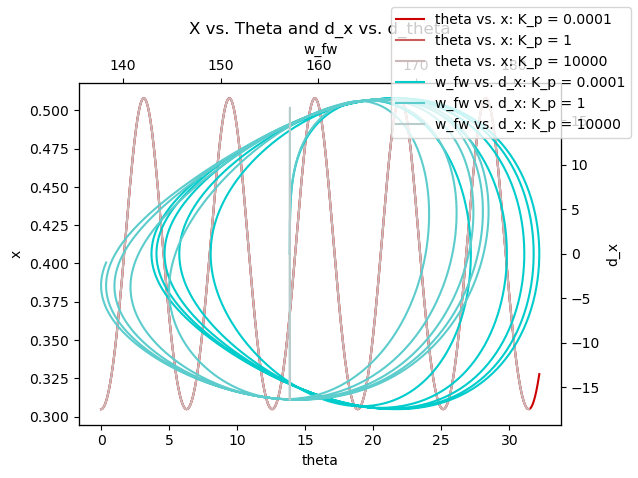

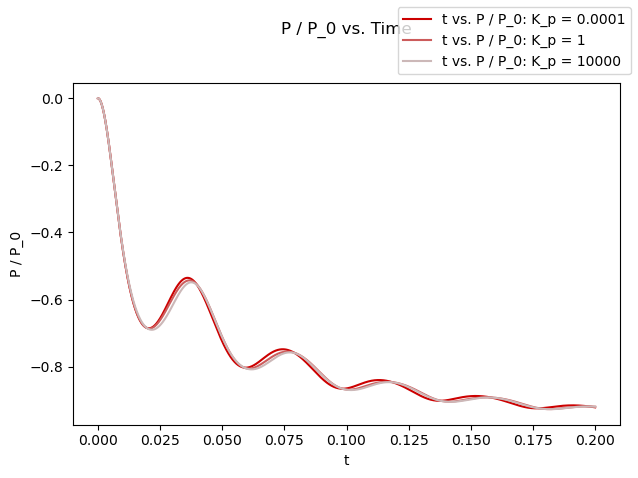

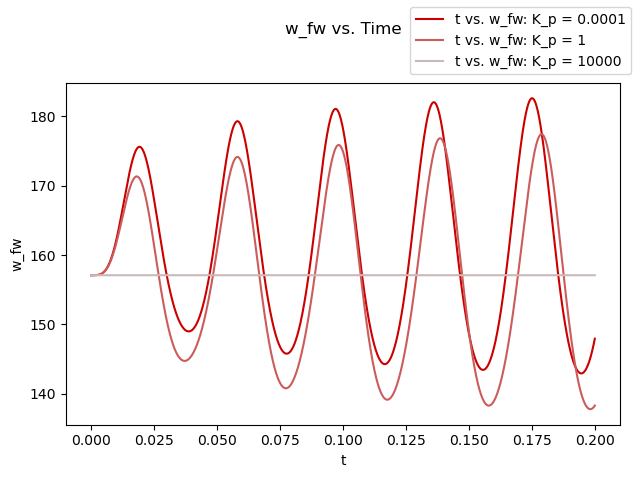

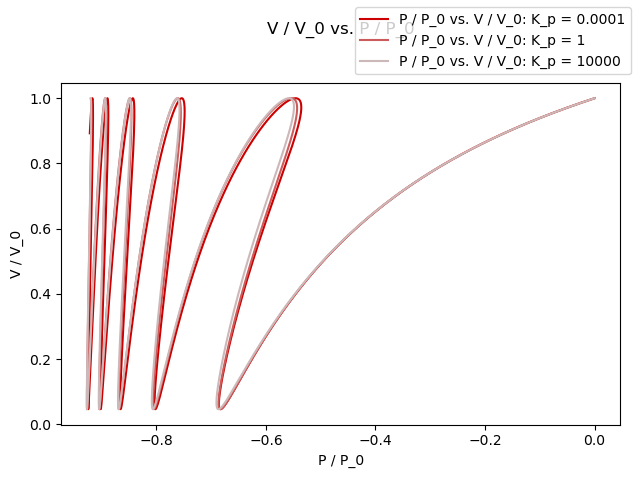

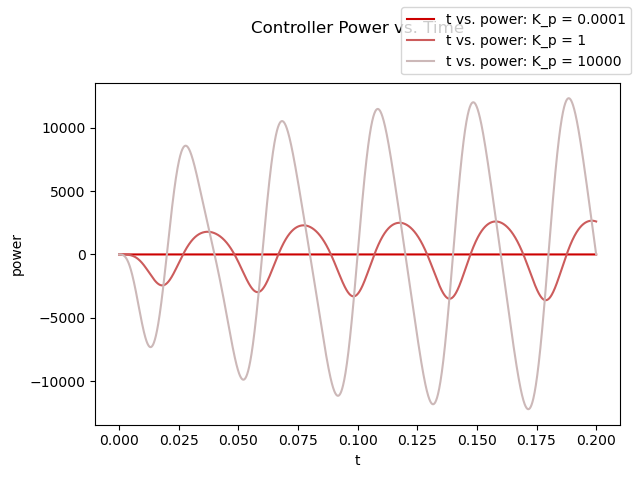

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from solve_problem import solve_problem
from plot import plot_2d, plot_ani
plt.rcParams["animation.html"] = "jshtml"

# -----------------------------
# Initial Global Parameters
# -----------------------------
params: dict[str, float] = {}

# Flywheel and piston rod
params["m_fw"] = 10 / 2.2       # Flywheel mass (lbs -> kg)
params["R"] = 4 * 0.0254        # Flywheel rod joint radius (in -> m)
params["L"] = 4 * params["R"]   # Rod length (m)
params["J_fw"] = params["m_fw"] * params["R"]**2 / 2    # Flywheel moment of inertia (kg * m^2)

# Piston
params["D_p"] = 4 * 0.0254                      # Piston diameter (in -> m)
params["A_p"] = np.pi * params["D_p"]**2 / 4    # Piston area (m^2)

# Air
params["V_st"] = params["A_p"] * 2 * params["R"]    # Volume displaced due to stroke (m^3)
params["V_TDC"] = 80 / 10**6                        # Volume remaining at top of stroke (cc -> m^3)
params["V_0"] = params["V_st"] + params["V_TDC"]    # Volume at BDC (m^3)
params["P_0"] = 1 * 10**5                           # Atmospheric pressure (atm -> Pa)
params["gamma"] = 1.4                               # Specific heat ratio

# Controller
params["w_fw_des"] = 1500 / 60 * 2 * np.pi  # Desired flywheel rotational speed (RPM -> rad/s)
params["K_p"] = 1   # Controller proportional gain

# Valves
params["d_o"] = 0.5 * 0.0254      # Outlet check-valve flow diameter (in -> m)
params["d_i"] = 0.5 * 0.0254      # Inlet check-valve flow diameter (in -> m)
params["A_o_nom"] = np.pi * params["d_o"]**2 / 4  # Outlet check-valve flow area (m)
params["A_i_nom"] = np.pi * params["d_i"]**2 / 4  # Inlet check-valve flow area (m)

# Accumulator
params["rho"] = 1.28                    # Air density at atmospheric pressure (kg/m^3)
params["c"] = 340                       # Air speed of sound (m/s)
params["V_acc"] = 5 * params["V_0"]     # Accumulator volume (m^3)
params["C_acc"] = params["V_acc"] / (params["rho"] * params["c"]**2)    # Accumulator compliance (m^4*s/kg)

# Time
t_start: float = 0
t_end: float = 0.2
t_increment: float = 0.0001

t_span = (t_start, t_end)
t_eval = np.arange(min(t_span), max(t_span)+t_increment, t_increment)


# Run simulations
solutions: list[str, dict[str, float]] = []
params["K_p"] = 0.0001
solutions.append(solve_problem(params, t_eval, f"K_p = {params['K_p']}"))

params["K_p"] = 1
solutions.append(solve_problem(params, t_eval, f"K_p = {params['K_p']}"))

params["K_p"] = 10000
solutions.append(solve_problem(params, t_eval, f"K_p = {params['K_p']}"))

# Plot figures
fig1 = plot_2d(solutions, [("theta", "x"), ("w_fw", "d_x")], "X vs. Theta and d_x vs. d_theta")
fig2 = plot_2d(solutions, [("t", "P / P_0")], "P / P_0 vs. Time")
fig3 = plot_2d(solutions, [("t", "w_fw")], "w_fw vs. Time")
fig4 = plot_2d(solutions, [("P / P_0", "V / V_0")], "V / V_0 vs. P / P_0")
fig5 = plot_2d(solutions, [("t", "power")], "Controller Power vs. Time")

plt.show()

## Conclusions
As can be seen above, several rotations of the flywheel are simulated with varying levels of controller gain $ K_p $ ranging from 0.0001 to 10000. This provided us with a large range of controller gain to work with and observe its effects on the system. As observed in the plot of w_fw vs Time, there is a big jump in angular velocity of the flywheel as we go from $ K_p = 0.01 $ to $ K_p = 1 $. This produces a more constant angular velocity over the time of the flywheel rotating. Going up from $K_p = 1$, we can see that the system starts to behave like a flat line. This in theory produces the most constant flywheel velocity, but the engergy cost of that type of controller would likely be very high, as seen in the Power vs. Time plot. We can see in the other plots that the simulation is behaving as we expect with the pressure and volume ratios approaching equilibrium.
